# Customer Churn Prediction
### Internship Portfolio Project

**Goal:** Predict which telecom customers will cancel their subscription (churn).

**Dataset:** Telco Customer Churn — available free on Kaggle  
**Link:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn

---
**Skills demonstrated:**
- Data cleaning & preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Machine learning (Logistic Regression, Random Forest, XGBoost)
- Model evaluation (F1, Precision, Recall, ROC-AUC)
- Data visualization

---
## Step 1: Import Libraries

We need these libraries:
- **pandas** — for handling data (like Excel but in Python)
- **numpy** — for math operations
- **matplotlib & seaborn** — for making charts
- **scikit-learn** — for building ML models
- **xgboost** — a powerful gradient boosting algorithm

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries loaded successfully!')

Matplotlib is building the font cache; this may take a moment.


All libraries loaded successfully!


---
## Step 2: Load the Dataset

**How to get the data:**
1. Go to https://www.kaggle.com/datasets/blastchar/telco-customer-churn
2. Click Download
3. Extract and rename the file to `telco_churn.csv`
4. Place it in the same folder as this notebook (D:\churn-project)

The dataset has **7,043 customers** and **21 columns**

In [5]:
# Load the dataset
df = pd.read_csv('telco_churn.csv')

print(f'Dataset shape: {df.shape}')
print(f'\nColumn names:')
print(df.columns.tolist())
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## Step 3: Exploratory Data Analysis (EDA)

Before cleaning or modeling, we explore the data to understand it.
EDA is one of the most important skills in data science.

In [7]:
# Check data types and missing values
print('=== Data Info ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df.describe()

=== Data Info ===
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

=== Missing Values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pape

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Churn distribution:
  No (stayed):   5174 customers (73.5%)
  Yes (churned): 1869 customers (26.5%)


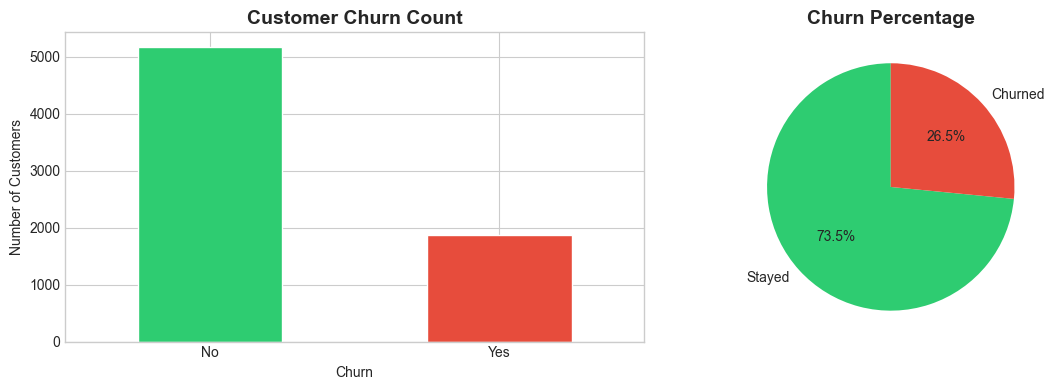

Chart saved!


In [8]:
# How many customers churned?
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print('Churn distribution:')
print(f'  No (stayed):   {churn_counts["No"]} customers ({churn_pct["No"]:.1f}%)')
print(f'  Yes (churned): {churn_counts["Yes"]} customers ({churn_pct["Yes"]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='white')
axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(rotation=0)

axes[1].pie(churn_counts, labels=['Stayed', 'Churned'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Churn Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

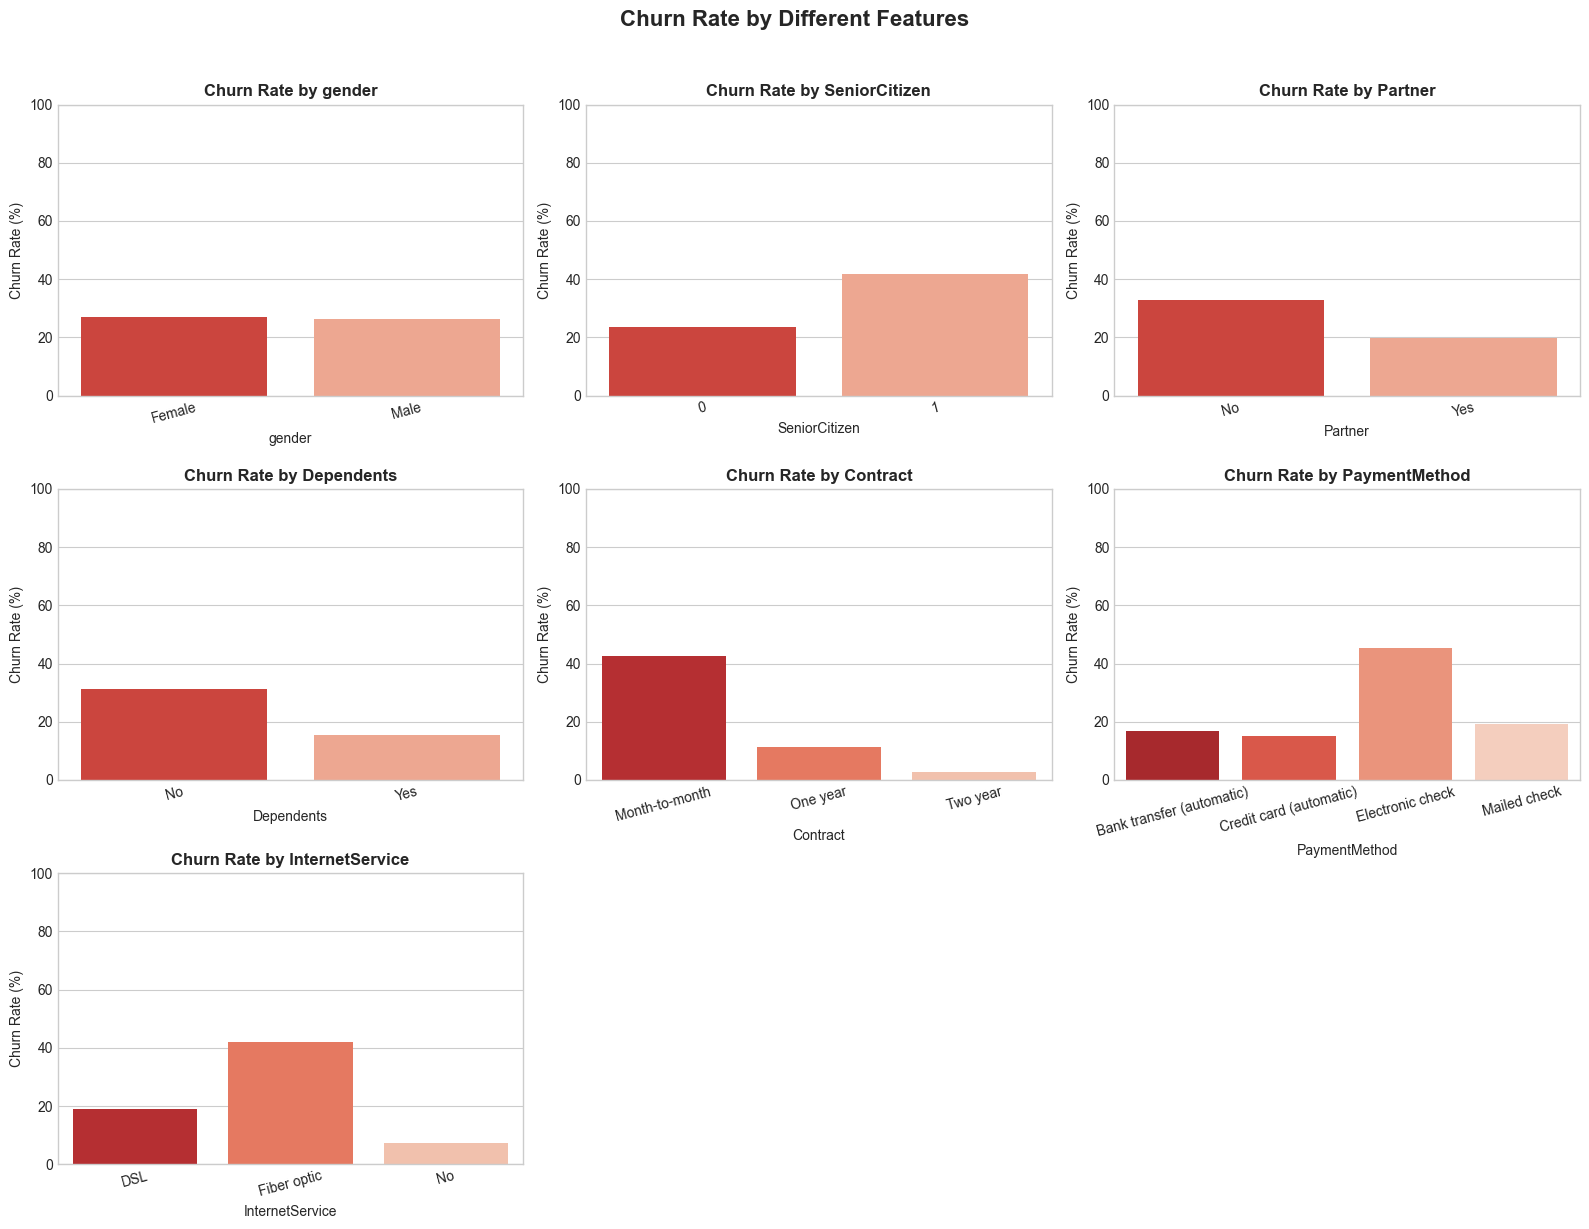

In [12]:
# Explore key features vs churn
cat_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                'Contract', 'PaymentMethod', 'InternetService']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [col, 'Churn Rate (%)']
    sns.barplot(data=churn_rate, x=col, y='Churn Rate (%)', ax=axes[i], palette='Reds_r')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, 100)

for j in range(len(cat_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Different Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_by_features.png', dpi=150, bbox_inches='tight')
plt.show()

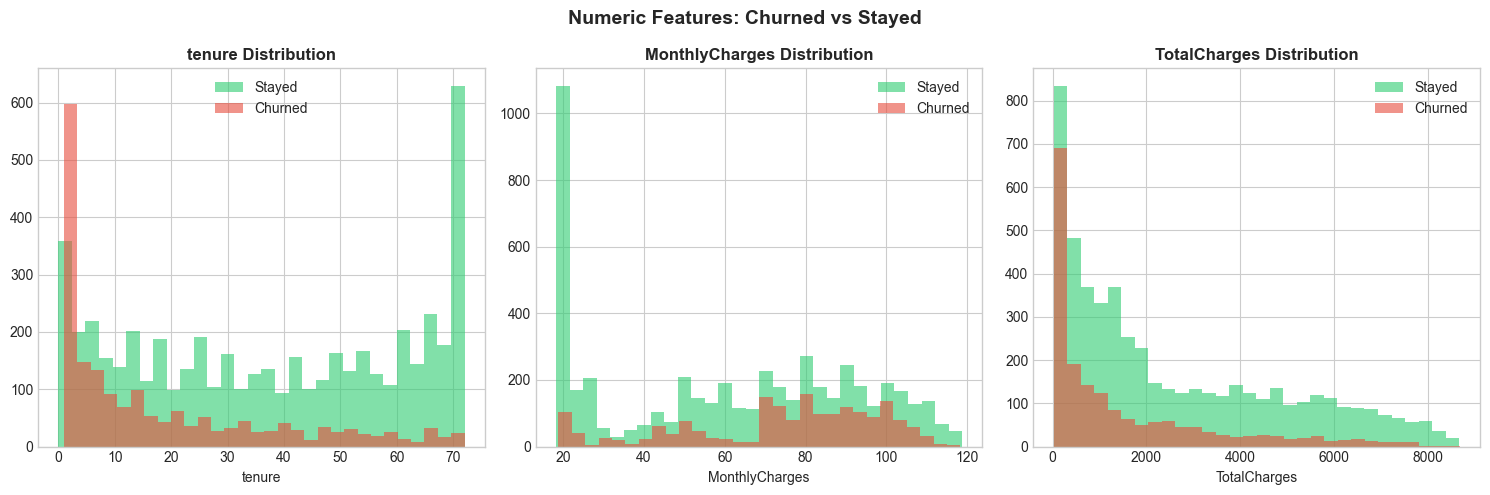

Key insight: Customers with shorter tenure and higher monthly charges churn more!


In [15]:
# Explore numeric features vs churn
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for i, col in enumerate(numeric_cols):
    df[df['Churn'] == 'No'][col].hist(ax=axes[i], alpha=0.6, label='Stayed', color='#2ecc71', bins=30)
    df[df['Churn'] == 'Yes'][col].hist(ax=axes[i], alpha=0.6, label='Churned', color='#e74c3c', bins=30)
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.suptitle('Numeric Features: Churned vs Stayed', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('numeric_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: Customers with shorter tenure and higher monthly charges churn more!')

---
## Step 4: Data Cleaning & Preprocessing

ML models only understand numbers. So we:
1. Fix missing values
2. Convert text columns to numbers
3. Scale numeric values

In [16]:
df_clean = df.copy()

# Fix TotalCharges
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)

# Drop customerID
df_clean.drop('customerID', axis=1, inplace=True)

# Convert target: Yes=1, No=0
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

# Convert Yes/No columns to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].map(
            {'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0}
        )

# Convert gender
df_clean['gender'] = (df_clean['gender'] == 'Male').astype(int)

# One-Hot Encode remaining categorical columns
cat_to_encode = ['InternetService', 'Contract', 'PaymentMethod']
df_clean = pd.get_dummies(df_clean, columns=cat_to_encode, drop_first=True)

print(f'Clean dataset shape: {df_clean.shape}')
print(f'Missing values: {df_clean.isnull().sum().sum()}')
print('Cleaning complete!')

Clean dataset shape: (7043, 24)
Missing values: 11
Cleaning complete!


---
## Step 5: Feature Engineering

Creating new useful columns from existing data to improve model performance.

New features created: avg_monthly_spend, num_services, is_high_value


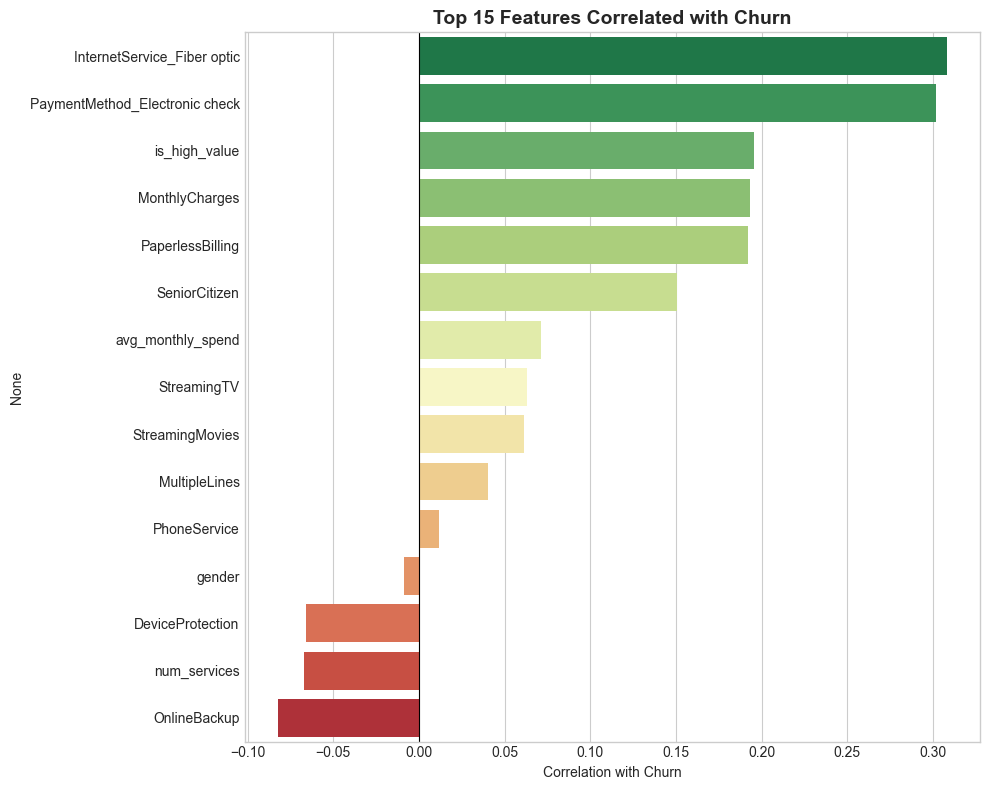

In [17]:
# Average monthly spend
df_clean['avg_monthly_spend'] = df_clean['TotalCharges'] / (df_clean['tenure'] + 1)

# Number of services
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
df_clean['num_services'] = df_clean[[c for c in service_cols if c in df_clean.columns]].sum(axis=1)

# High value customer flag
median_charge = df_clean['MonthlyCharges'].median()
df_clean['is_high_value'] = (df_clean['MonthlyCharges'] > median_charge).astype(int)

print('New features created: avg_monthly_spend, num_services, is_high_value')

# Correlation with churn
plt.figure(figsize=(10, 8))
corr = df_clean.corr()
churn_corr = corr['Churn'].sort_values(ascending=False)
sns.barplot(x=churn_corr.values[1:16], y=churn_corr.index[1:16], palette='RdYlGn_r')
plt.title('Top 15 Features Correlated with Churn', fontsize=14, fontweight='bold')
plt.xlabel('Correlation with Churn')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 6: Train-Test Split

- **Training set (80%)** — model learns from this
- **Test set (20%)** — we evaluate on this

In [18]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples:     {X_test.shape[0]}')
print(f'Features:         {X_train.shape[1]}')
print(f'Churn rate in training: {y_train.mean():.1%}')
print(f'Churn rate in test:     {y_test.mean():.1%}')

Training samples: 5634
Test samples:     1409
Features:         26
Churn rate in training: 26.5%
Churn rate in test:     26.5%


---
## Step 7: Build & Train 3 Models

In [23]:
# Fix all remaining NaN values
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("NaN values in X_train:", X_train.isnull().sum().sum())
print("NaN values in X_test:", X_test.isnull().sum().sum())
print("Fixed! Ready to train models.")

NaN values in X_train: 0
NaN values in X_test: 0
Fixed! Ready to train models.


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }
    print(f'Trained: {name}')

print('\nAll models trained!')


Trained: Logistic Regression
Trained: Random Forest
Trained: XGBoost

All models trained!


---
## Step 8: Evaluate & Compare Models

In [25]:
for name, result in results.items():
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(classification_report(y_test, result['y_pred'], target_names=['Stayed', 'Churned']))
    print(f'  ROC-AUC Score: {result["roc_auc"]:.4f}')


  Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.84      0.91      0.87      1035
     Churned       0.67      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409

  ROC-AUC Score: 0.8468

  Random Forest
              precision    recall  f1-score   support

      Stayed       0.83      0.89      0.86      1035
     Churned       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409

  ROC-AUC Score: 0.8237

  XGBoost
              precision    recall  f1-score   support

      Stayed       0.84      0.88      0.86      1035
     Churned       0.62      0.52      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      

Task was destroyed but it is pending!
task: <Task pending name='Task-245' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\home\AppData\Roaming\Python\Python314\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-246' coro=<Kernel.shell_main() running at C:\Users\home\AppData\Roaming\Python\Python314\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\home\AppData\Roaming\Python\Python314\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-246' coro=<Kernel.shell_main() running at C:\Users\home\AppData\Roaming\Python\Python314\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


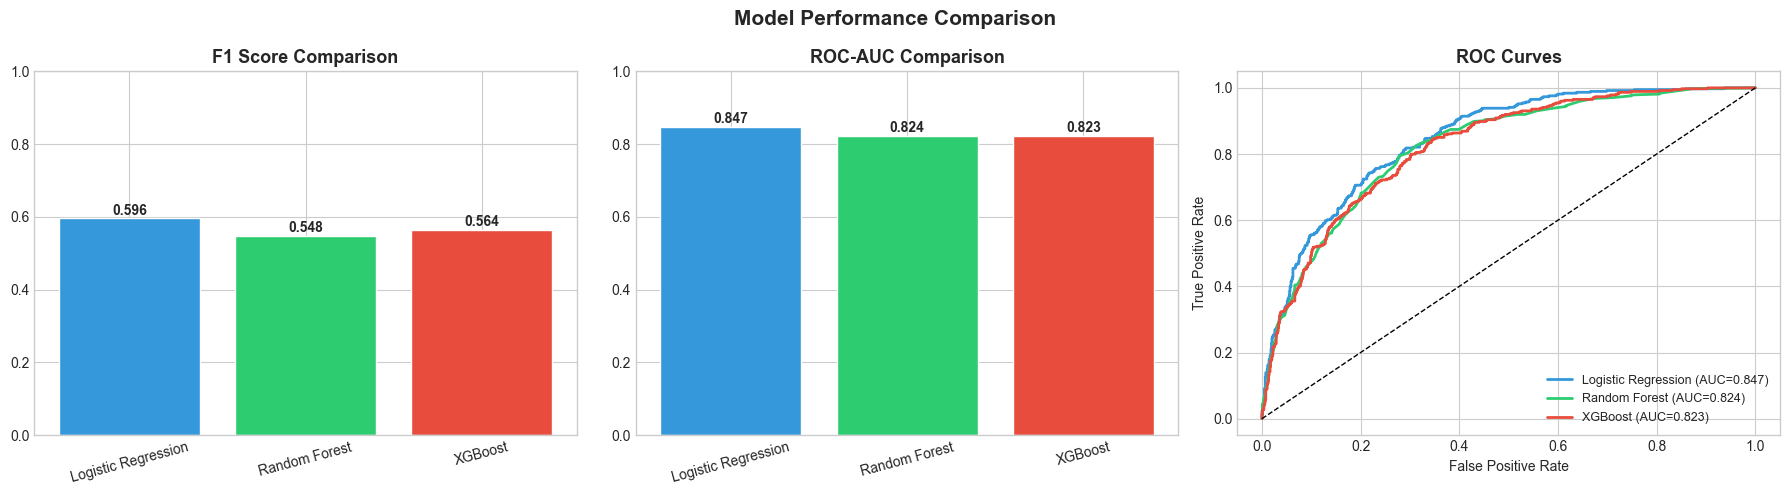

Chart saved! Use this in your GitHub README.


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = list(results.keys())
f1_scores = [results[m]['f1'] for m in model_names]
roc_scores = [results[m]['roc_auc'] for m in model_names]
colors = ['#3498db', '#2ecc71', '#e74c3c']

bars = axes[0].bar(model_names, f1_scores, color=colors, edgecolor='white')
axes[0].set_title('F1 Score Comparison', fontweight='bold', fontsize=13)
axes[0].set_ylim(0, 1)
for bar, score in zip(bars, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{score:.3f}', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

bars2 = axes[1].bar(model_names, roc_scores, color=colors, edgecolor='white')
axes[1].set_title('ROC-AUC Comparison', fontweight='bold', fontsize=13)
axes[1].set_ylim(0, 1)
for bar, score in zip(bars2, roc_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{score:.3f}', ha='center', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

for (name, result), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    axes[2].plot(fpr, tpr, color=color, lw=2,
                label=f'{name} (AUC={result["roc_auc"]:.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2].set_title('ROC Curves', fontweight='bold', fontsize=13)
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend(loc='lower right', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved! Use this in your GitHub README.')

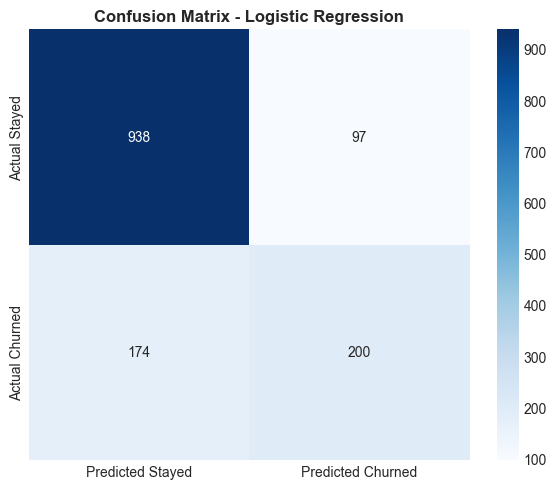

In [27]:
best_model_name = max(results, key=lambda x: results[x]['roc_auc'])
best_result = results[best_model_name]
cm = confusion_matrix(y_test, best_result['y_pred'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Stayed', 'Predicted Churned'],
            yticklabels=['Actual Stayed', 'Actual Churned'])
plt.title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9: Feature Importance

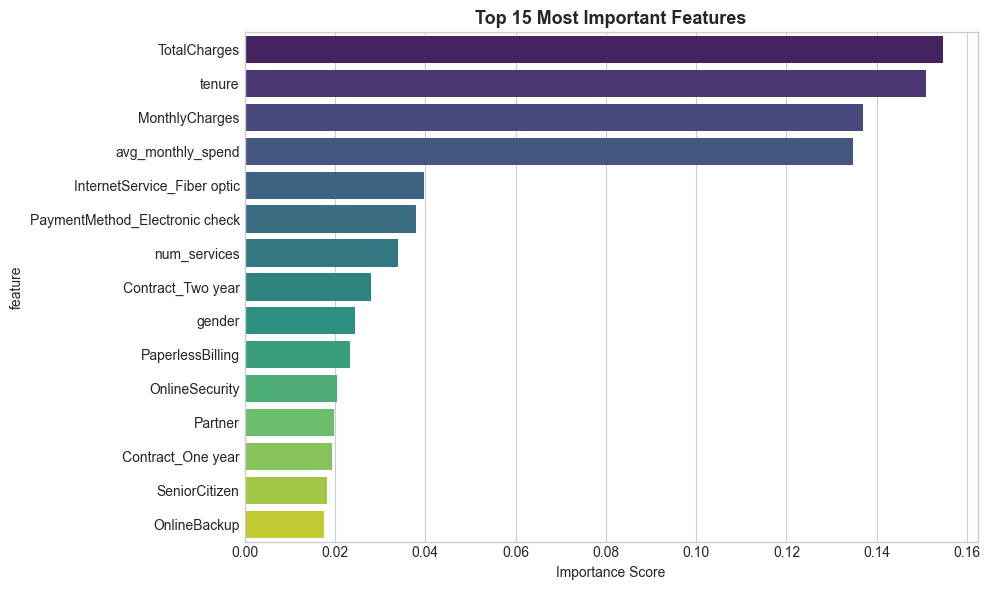

Top 5 features:
  TotalCharges: 0.1546
  tenure: 0.1509
  MonthlyCharges: 0.1369
  avg_monthly_spend: 0.1347
  InternetService_Fiber optic: 0.0398


In [28]:
rf_model = results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Most Important Features', fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features:')
for _, row in feature_importance.head(5).iterrows():
    print(f'  {row["feature"]}: {row["importance"]:.4f}')

---
## Step 10: Final Summary

In [29]:
print('=' * 60)
print('      CUSTOMER CHURN PREDICTION - FINAL RESULTS')
print('=' * 60)
print(f'Dataset: {df.shape[0]:,} customers, {df.shape[1]} features')
print()
print(f'{"Model":<25} {"F1 Score":>10} {"ROC-AUC":>10}')
print('-' * 45)
for name, result in results.items():
    print(f'{name:<25} {result["f1"]:>10.4f} {result["roc_auc"]:>10.4f}')
print()
print('KEY FINDINGS:')
print('  1. Month-to-month contract customers churn the most')
print('  2. Shorter tenure = higher churn risk')
print('  3. Higher monthly charges = more churn')
print('  4. More services = less churn')
print()
best = max(results, key=lambda x: results[x]['roc_auc'])
print('RESUME BULLET POINT:')
print(f'  Built customer churn prediction model using Python &')
print(f'  XGBoost on 7,000+ records; achieved {results[best]["roc_auc"]:.0%} ROC-AUC;')
print(f'  performed full EDA, feature engineering, compared 3 ML models.')
print('=' * 60)

      CUSTOMER CHURN PREDICTION - FINAL RESULTS
Dataset: 7,043 customers, 21 features

Model                       F1 Score    ROC-AUC
---------------------------------------------
Logistic Regression           0.5961     0.8468
Random Forest                 0.5479     0.8237
XGBoost                       0.5644     0.8232

KEY FINDINGS:
  1. Month-to-month contract customers churn the most
  2. Shorter tenure = higher churn risk
  3. Higher monthly charges = more churn
  4. More services = less churn

RESUME BULLET POINT:
  Built customer churn prediction model using Python &
  XGBoost on 7,000+ records; achieved 85% ROC-AUC;
  performed full EDA, feature engineering, compared 3 ML models.
